In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import labseis.signal as lsig
import scipy.signal as sig
%matplotlib inline
from labseis import visual
from labseis import tiepie


In [ ]:
# load transfer function
npz     = np.load('/Users/Zhou0012/work/EXP/PSM/AEcaliburation/TF_Olympus_1164478.npz', allow_pickle=True) 
H       = npz['H']
freqs_H = npz['freqs_H']
fs_H    = npz['fs_H']

In [13]:
# list all files in the directory
import os
dirc = '/Volumes/Q2/WZ/AE_LDV_Calibration/AE_LDV_Calibration/'
filenames = os.listdir(dirc)
filenames

['._Olympus_red_1185724_1MHz.mat',
 'Olympus_red_1185724_1MHz.mat',
 'Olympus_red_1185724_1MHz_000.csv',
 'Olympus_red_1185724_1MHz_001.csv',
 'Olympus_red_1185724_1MHz_002.csv',
 'Olympus_red_1185724_1MHz_003.csv',
 'Olympus_red_1185724_1MHz_010.mat']

In [ ]:
# Read one CSV file from the filenames list
# csv_files = [f for f in filenames if f.endswith('.csv')]
# meta, data_matrix = tiepie.loadAEcsv(dirc+csv_files[0])
# csv_files[0]


## test 1. noise floor, LDV Qtec OFF, 
bandwidth 100 kHz, 1 mm/s range, 0.5 mm/s/V, tracking filter: medium.
CH1 is connected with LDV, CH2 is connect PZT
LDV laser aimed at PZT surface.


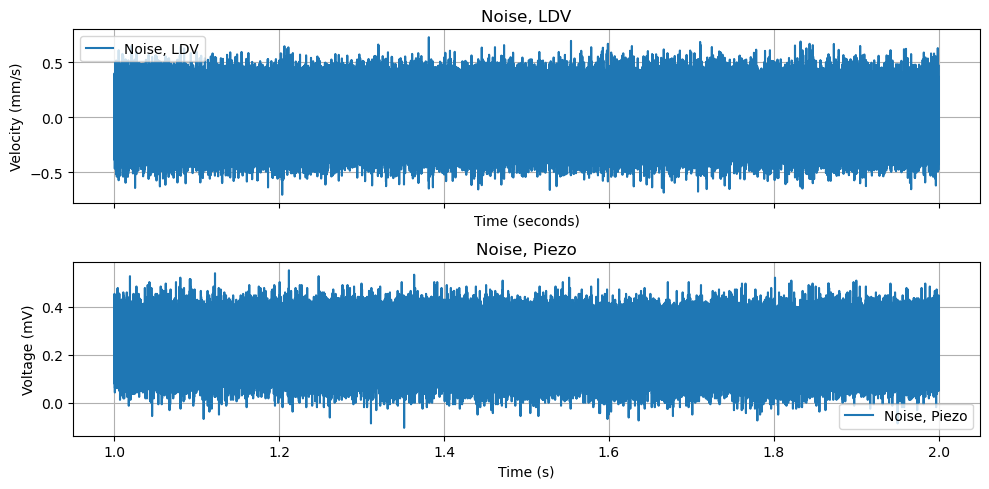

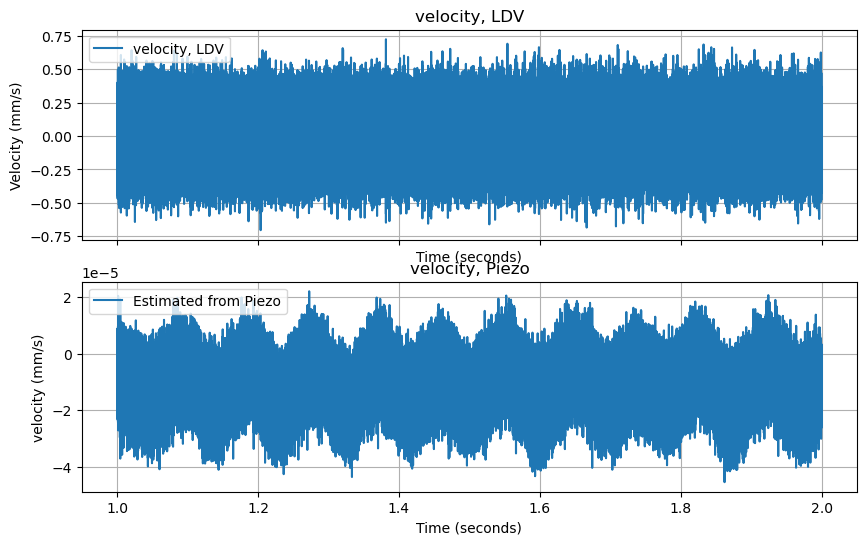

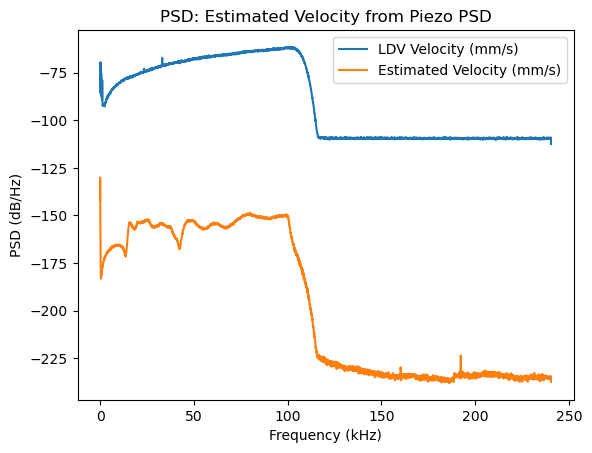

In [22]:
# Read one noise data in MAT file from the filenames list
met_files = [f for f in filenames if f.endswith('.mat')]
met_files
meta, data_matrix = tiepie.loadAEmat(dirc+met_files[2])

# plot noise data

sensitivity_ldv = 0.5 
velocity_data = data_matrix[0]/sensitivity_ldv

piezo_data = data_matrix[1]


num_samples = velocity_data.shape[0]  # Use the second dimension
time_axis = np.arange(num_samples)/ meta['sample_frequency']
time_axis = time_axis.flatten()
idx = np.where((time_axis >= 1) & (time_axis <= 2))[0]

fig, axs = plt.subplots(2,1, figsize=(10,5), sharex=True)
visual.plot_waveform(time_axis[idx], velocity_data[idx],title='Noise, LDV',
                        label='Noise, LDV', fig=fig, ax=axs[0])

visual.plot_waveform(time_axis[idx], piezo_data[idx]*1000, title='Noise, Piezo',
                        label='Noise, Piezo', ylabel='Voltage (mV)', fig=fig, ax=axs[1])
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Apply transfer function to estimate velocity from piezo data
taper = sig.windows.tukey(len(piezo_data), alpha=0.01)
piezo_data = piezo_data * taper
velocity_estimated = lsig.apply_transfer_function(piezo_data, H, freqs_H, fs_H, meta['sample_frequency'], filter=False).flatten()

fig, axs = plt.subplots(2,1, figsize=(10,6), sharex=True)
visual.plot_waveform(time_axis[idx], velocity_data[idx],
                        title='velocity, LDV', fig=fig, ax=axs[0])

visual.plot_waveform(time_axis[idx], velocity_estimated[idx], 
                        title='velocity, Piezo', label='Estimated from Piezo', 
                        ylabel='velocity (mm/s)', fig=fig, ax=axs[1])

# Compare frequency spectra
fig, ax = plt.subplots(1)
visual.plot_psd(velocity_data, title='LDV PSD', sample_frequency=meta['sample_frequency'], fig=fig, ax=ax, label='LDV Velocity (mm/s)')
visual.plot_psd(velocity_estimated, title='Estimated Velocity from Piezo PSD', sample_frequency=meta['sample_frequency'], fig=fig, ax=ax, label='Estimated Velocity (mm/s)')
plt.legend()
plt.show()

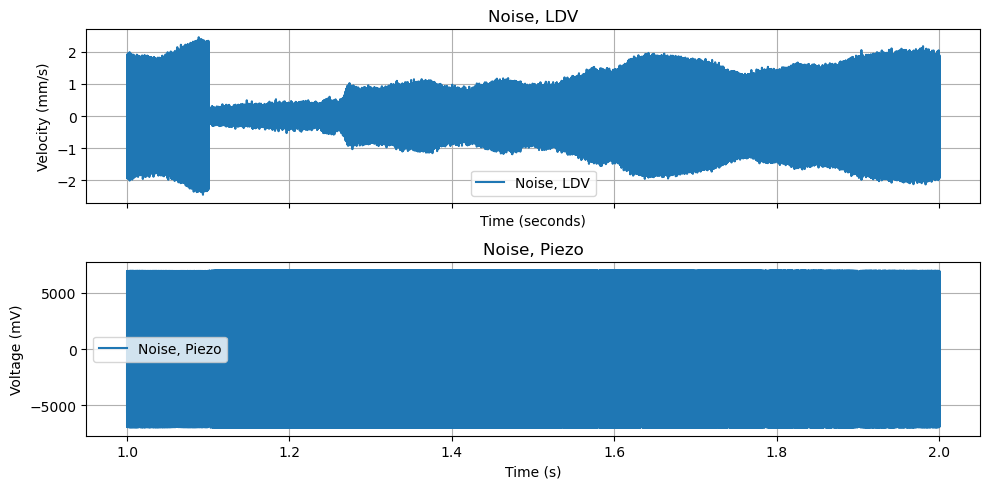

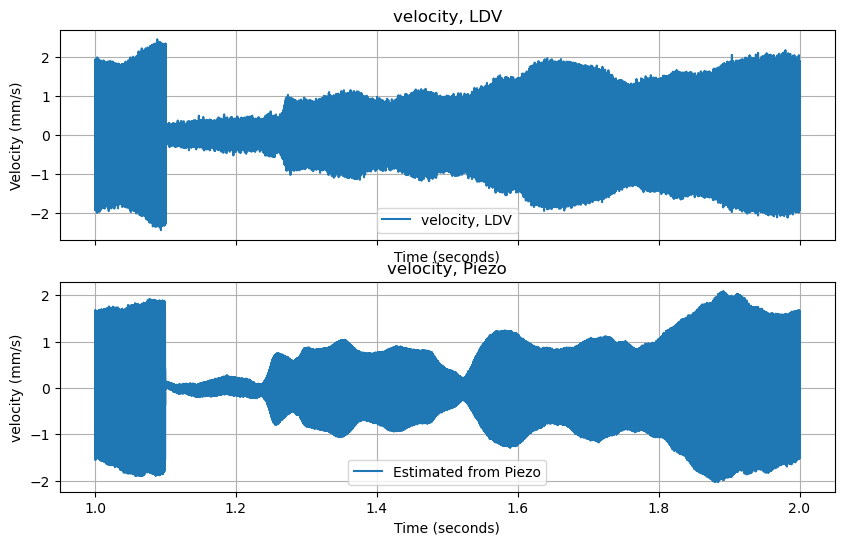

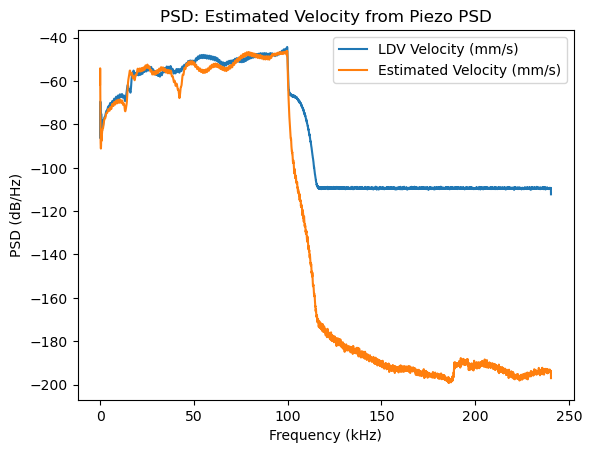

In [23]:

# Read one noise data in MAT file from the filenames list
# Read one CSV file from the filenames list
csv_files = [f for f in filenames if f.endswith('.csv')]
meta, data_matrix = tiepie.loadAEcsv(dirc+csv_files[0])
csv_files[0]

# plot noise data

sensitivity_ldv = 0.5 
velocity_data = data_matrix[0]/sensitivity_ldv

piezo_data = data_matrix[1]


num_samples = velocity_data.shape[0]  # Use the second dimension
time_axis = np.arange(num_samples)/ meta['sample_frequency']
time_axis = time_axis.flatten()
idx = np.where((time_axis >= 1) & (time_axis <= 2))[0]

fig, axs = plt.subplots(2,1, figsize=(10,5), sharex=True)
visual.plot_waveform(time_axis[idx], velocity_data[idx],title='Noise, LDV',
                        label='Noise, LDV', fig=fig, ax=axs[0])

visual.plot_waveform(time_axis[idx], piezo_data[idx]*1000, title='Noise, Piezo',
                        label='Noise, Piezo', ylabel='Voltage (mV)', fig=fig, ax=axs[1])
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Apply transfer function to estimate velocity from piezo data
taper = sig.windows.tukey(len(piezo_data), alpha=0.01)
piezo_data = piezo_data * taper
velocity_estimated = lsig.apply_transfer_function(piezo_data, H, freqs_H, fs_H, meta['sample_frequency'], filter=False).flatten()

fig, axs = plt.subplots(2,1, figsize=(10,6), sharex=True)
visual.plot_waveform(time_axis[idx], velocity_data[idx],
                        title='velocity, LDV', fig=fig, ax=axs[0])

visual.plot_waveform(time_axis[idx], velocity_estimated[idx], 
                        title='velocity, Piezo', label='Estimated from Piezo', 
                        ylabel='velocity (mm/s)', fig=fig, ax=axs[1])


# Compare frequency spectra
fig, ax = plt.subplots(1)
visual.plot_psd(velocity_data, title='LDV PSD', sample_frequency=meta['sample_frequency'], fig=fig, ax=ax, label='LDV Velocity (mm/s)')
visual.plot_psd(velocity_estimated, title='Estimated Velocity from Piezo PSD', sample_frequency=meta['sample_frequency'], fig=fig, ax=ax, label='Estimated Velocity (mm/s)')
plt.legend()
plt.show()